GP

In [2]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./GP_AL_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../../result_plot/pan_5/GP_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[38.15475355807601, 22.387507458278343, 19.80773938340399, 15.526108879265061, 12.885223411405452, 10.327175355480401, 8.893824829364236, 8.247369997973516, 7.0979289111513255, 6.534230817191299, 5.576261213864264, 4.9637856791297414, 4.27342373889672, 3.5944678461181256, 3.388375432448818, 3.044408239652572, 2.7954517987340983, 2.6229982518384247, 2.468602137531574, 2.3094564955215398, 2.169606460620578]


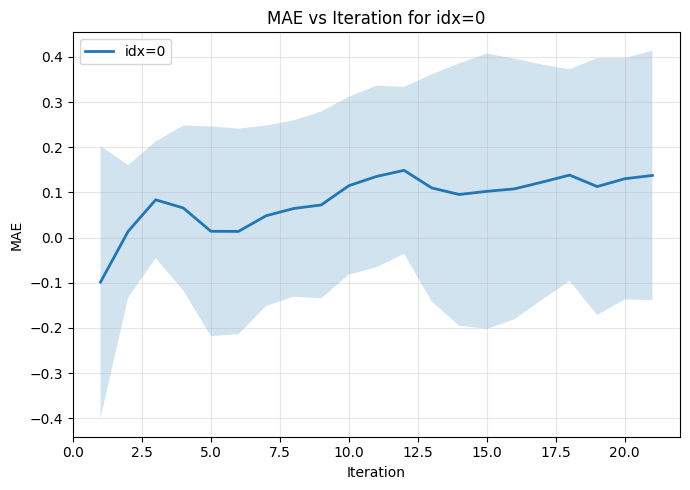

In [8]:
import matplotlib.pyplot as plt

def plot_metric_by_idx(
    avg_by_idx,
    metric='mae',          # 你自己改：'mae' / 'rmse' / 'r2'
    idx=0,         # 你自己改：例如 [0,1,2]；None 表示全部
    title=None,
    xlabel='Iteration',
    ylabel=None,
    figsize=(7, 5),
):

    n_steps = len(avg_by_idx[idx][f'{metric}_mean'])
    x = np.arange(1, n_steps + 1)

    plt.figure(figsize=figsize)

    mean = np.array(avg_by_idx[idx][f'{metric}_mean'])
    std = np.array(avg_by_idx[idx][f'{metric}_std'])

    plt.plot(x, mean, label=f'idx={idx}', linewidth=2)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel else metric.upper())
    plt.title(title if title else f'{metric.upper()} vs Iteration')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric_by_idx(avg_by_idx, metric='r2', idx=0, title='MAE vs Iteration for idx=0', ylabel='MAE')

AL

In [1]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./AM_AL_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../../result_plot/pan_5/AL_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[22.71948503100332, 23.3290492475296, 17.600802010125722, 15.482339154586157, 12.909344333278915, 10.026331589952282, 10.216525791566875, 7.628366348048877, 6.670465527576269, 5.7471530749254205, 4.928570652421743, 3.5510099778683695, 3.390592385880801, 2.034404546513314, 1.9508234505698003, 2.328275851838202, 1.7788771068862541, 1.5618387841690253, 1.5792983857216576, 1.0241997127398936, 1.009770031620721]


QBC


In [3]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./QBC_AL_PAN_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../../result_plot/pan_5/QBC_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[20.27718686249972, 18.865854497772986, 18.053198351951153, 18.55739135816832, 18.96874031979575, 18.964771510704743, 18.519944532933042, 18.48125904810461, 18.408647097489165, 17.98561875077524, 17.655698293079787, 17.53672285641202, 18.03420089274259, 18.190854137935332, 18.158273661669305, 18.11360313605555, 17.920434808129137, 17.759777351829975, 17.969536221172444, 17.826945474388516, 17.779518268445837]


qbc alt

In [1]:
import numpy as np
import json
results = []
grouped = {}
avg_by_idx = {}

seeds = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
idxs = [0, 1, 2]

avg_by_idx = {}

for idx in idxs:
    mae_all = []
    rmse_all = []
    r2_all = []

    for seed in seeds:
        gp_path = f'./QBC_ALT_AL_PAN_results_seed_{seed}_{idx}.json'
        with open(gp_path, 'r') as f:
            data = json.load(f)

        # 每个都是长度21的序列
        mae_all.append(data['mae'])
        rmse_all.append(data['rmse'])
        r2_all.append(data['r2'])

    mae_all = np.array(mae_all)    # shape: [n_seed, 21]
    rmse_all = np.array(rmse_all)  # shape: [n_seed, 21]
    r2_all = np.array(r2_all)      # shape: [n_seed, 21]

    avg_by_idx[idx] = {
        'mae_mean': mae_all.mean(axis=0).tolist(),     # 长度21
        'mae_std': mae_all.std(axis=0).tolist(),       # 长度21
        'rmse_mean': rmse_all.mean(axis=0).tolist(),   # 长度21
        'rmse_std': rmse_all.std(axis=0).tolist(),     # 长度21
        'r2_mean': r2_all.mean(axis=0).tolist(),       # 长度21
        'r2_std': r2_all.std(axis=0).tolist(),         # 长度21
    }

# 例子：看 idx=0 的 mae 平均曲线（21步）
print(len(avg_by_idx[0]['mae_mean']))  # 21
print(avg_by_idx[0]['mae_mean'])


summary_json_path = '../result_plot/QBC_ALT_metrics_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(avg_by_idx, f, ensure_ascii=False, indent=2)

21
[20.694807389038658, 22.60803045090092, 22.175481815295477, 21.60084333531046, 19.939417923408087, 19.35282337160678, 19.655604568202925, 19.711747921250282, 19.77134419644568, 19.09200389216591, 18.720233900903775, 18.813776753268154, 19.363413185554855, 18.7034490979352, 18.88959907097188, 18.729073620208602, 18.648025337830212, 19.152693735005503, 19.098705936600183, 19.061579640685405, 19.07249612926023]
